# 1 &middot; Building the Deformation Gradient

Every later tutorial leans on the **deformation gradient** $F$, so here we build it by hand. A
deformation maps each rest point $X$ to a deformed point $x = \phi(X)$, and $F$ is its Jacobian: a local
linear map that says how a tiny chunk of material around $X$ is stretched and rotated. On a single
triangle the map is **affine**, $x = FX + t$, so $F$ is one constant $2\times 2$ matrix we can solve for directly.

$$
F = \frac{\partial x}{\partial X}
$$

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import igl
import simkit
import utils

NOTEBOOK = "001_deformation_gradient_construction"                 # this file's name
RESULTS_DIR = simkit.filesystem.notebook_results_path(NOTEBOOK)     # results/001_deformation_gradient_construction/
MEDIA_DIR = "media"                                                 # tracked copies for the website
# single triangle and its test deformations
SIDE = 1.0                      # side length of the equilateral rest triangle
ROT_DEG = 30.0                  # rotation angle of the rigid test motion (degrees)
TRANSLATION = [2.0, -1.0]       # translation of the rigid test motion
SCALE = [1.6, 0.7]              # axis-aligned stretch factors (x, y)
SHEAR_K = 0.7                   # simple shear, x += k * y
# mesh experiment
NX, NY = 13, 4                  # grid resolution (vertices)
WIDTH, HEIGHT = 2.0, 0.5        # rest strip size
BEND_RADIUS = 0.8               # radius of the arc the strip is bent onto
# convergence of F to the exact Jacobian
X_PROBE = [0.3, 0.1]                              # material point where F is compared with d(phi)/dX
H_LIST = [0.4, 0.2, 0.1, 0.05, 0.025, 0.0125]     # side lengths of the shrinking probe triangle

## Eliminate the translation with edge vectors

Subtracting vertex 0 from vertices 1 and 2 cancels the unknown translation: $x_i - x_0 = F\,(X_i - X_0)$.
Stacking the two rest edges as the columns of $D_m = [\,X_1-X_0,\; X_2-X_0\,]$ and the deformed edges as
$D_s = [\,x_1-x_0,\; x_2-x_0\,]$ gives $D_s = F D_m$, so two edge matrices and one inverse are all it takes.
The cell below codes this and checks it on the identity and on a rotation plus a translation.

$$
\boxed{\,F = D_s\, D_m^{-1}\,}
$$

In [2]:
def deformation_gradient_triangle(X, U):
    """F for a single triangle, built from rest edges (X) and deformed edges (U)."""
    Dm = np.column_stack([X[1] - X[0], X[2] - X[0]])   # rest edge vectors
    Ds = np.column_stack([U[1] - U[0], U[2] - U[0]])   # deformed edge vectors
    F = Ds @ np.linalg.inv(Dm)
    return F

X = SIDE * np.array([[-0.5, 0.0], [0.5, 0.0], [0.0, np.sqrt(3) / 2]])    # equilateral rest triangle
theta = np.deg2rad(ROT_DEG)
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
U_rot = X @ R.T + np.array(TRANSLATION)                                  # rotate AND translate

print("rest -> rest gives the identity:\n", np.round(deformation_gradient_triangle(X, X), 6))
print(f"\nrotate {ROT_DEG:g} deg + translate -> F is exactly that rotation:\n",
      np.round(deformation_gradient_triangle(X, U_rot), 6))

rest -> rest gives the identity:
 [[1. 0.]
 [0. 1.]]

rotate 30 deg + translate -> F is exactly that rotation:
 [[ 0.866025 -0.5     ]
 [ 0.5       0.866025]]


The identity comes back unchanged, and rotate + translate returns exactly the rotation matrix, with
$\det F = 1$ (no area change). The translation drops out because $F$ is built from *edges*, which a
translation leaves unchanged: $F$ sees only the triangle's shape, not where it sits.

## Seeing $D_m$ and $D_s$

The triangle is our whole mesh, one element `T = [[0, 1, 2]]`. The orange arrows are the columns of $D_m$
(left, at rest) and of $D_s$ (right, after the rotation + translation). $F$ is the linear map that carries
the left pair of arrows onto the right pair.

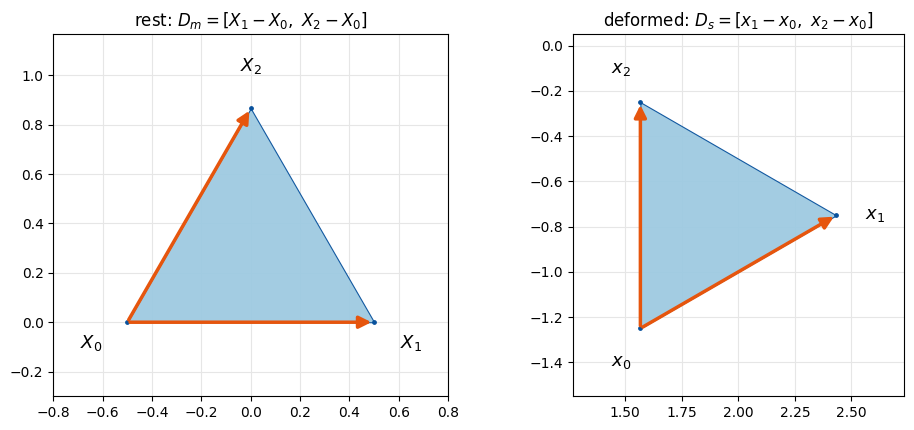

In [3]:
T = np.array([[0, 1, 2]])                       # one triangle, vertices 0, 1, 2
panels = [(r"rest: $D_m = [X_1 - X_0,\ X_2 - X_0]$", X, "X"),
          (r"deformed: $D_s = [x_1 - x_0,\ x_2 - x_0]$", U_rot, "x")]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
for ax, (title, P, sym) in zip(axes, panels):
    utils.plot_mesh(ax, P, T, title=title, lims=utils.auto_limits([P], pad=0.3), show_vertices=True)
    for i in (1, 2):
        ax.annotate("", xy=P[i], xytext=P[0], zorder=6,
                    arrowprops=dict(arrowstyle="-|>", color=utils.HANDLE_C, lw=2.5, mutation_scale=18))
    centroid = P.mean(axis=0)
    for i, p in enumerate(P):
        offset = 0.17 * (p - centroid) / np.linalg.norm(p - centroid)
        ax.text(*(p + offset), f"${sym}_{i}$", ha="center", va="center", fontsize=13)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "edge_vectors.png"),
                              copy_to=os.path.join(MEDIA_DIR, "001_edge_vectors.png"))
plt.show()

## The same thing, for any simplex: `simkit.deformation_gradient`

SimKit computes $F$ for triangles *and* tetrahedra through a reference-element shape-function gradient
(the matrix `H`), but the result is the same $D_s D_m^{-1}$. The printout confirms that it matches our
hand-built $F$ for the rotated triangle.

In [4]:
F_ours = deformation_gradient_triangle(X, U_rot)
F_simkit = simkit.deformation_gradient(X, T, U_rot)[0]    # [0] = first (only) element

print("match:", np.allclose(F_ours, F_simkit))
print(np.round(F_simkit, 6))

match: True
[[ 0.866025 -0.5     ]
 [ 0.5       0.866025]]


## Seeing it

Three deformations of the rest triangle (dashed), each labelled with the $F$ we built. Despite the large
translation, the first $F$ is a pure rotation with $\det F = 1$. Scaling puts the stretch factors on the
diagonal ($\det F = 1.6 \cdot 0.7 = 1.12$, the area grows), and the shear puts $k$ off the diagonal while
keeping the area ($\det F = 1$).

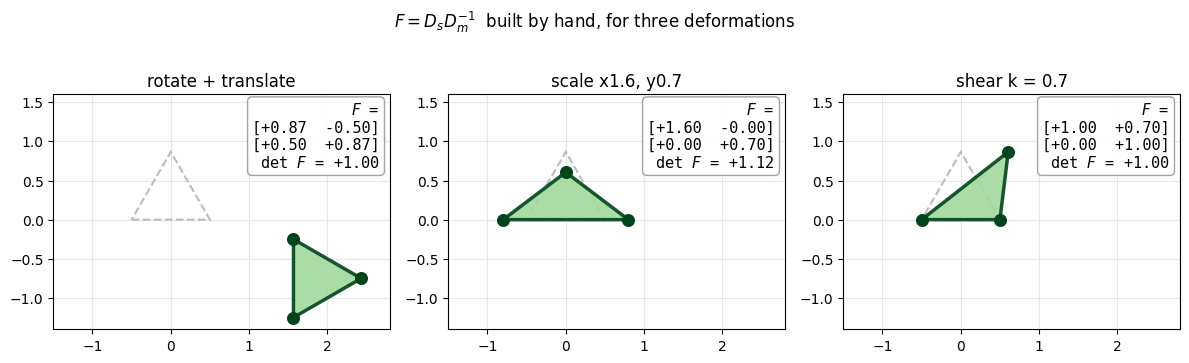

In [5]:
cases = [("rotate + translate", U_rot),
         (f"scale x{SCALE[0]:g}, y{SCALE[1]:g}", X * np.array(SCALE)),
         (f"shear k = {SHEAR_K:g}", X @ np.array([[1.0, SHEAR_K], [0.0, 1.0]]).T)]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, (name, U) in zip(axes, cases):
    utils.setup_axes(ax, (-1.5, 2.8), (-1.4, 1.6), title=name)
    utils.TriangleArtist(ax, U, rest=X)
    utils.text_box(ax, utils.format_F(deformation_gradient_triangle(X, U)), loc="upper right")
fig.suptitle(r"$F = D_s D_m^{-1}$  built by hand, for three deformations")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "deformations.png"),
                              copy_to=os.path.join(MEDIA_DIR, "001_deformations.png"))
plt.show()

## One $F$ per element on a mesh

`simkit.deformation_gradient(X, T, U)` is vectorised: one $F$ per triangle of a whole mesh. We deform a
libigl strip affinely ($A$ = the shear after the scale) and by bending it onto an arc of radius $R$,
$\phi(X) = \big((R+X_2)\sin\tfrac{X_1}{R},\ (R+X_2)\cos\tfrac{X_1}{R} - R\big)$, whose exact $\det F = (R + X_2)/R$.
The printout checks our formula against simkit on every triangle, confirms $F = A$ everywhere for the affine map,
and shows that the bend's per-triangle $\det F$ spans the exact range to within about 1%.

In [6]:
V, T_grid = igl.triangulated_grid(NX, NY)                  # unit square, NX x NY vertices
X_grid = (V - 0.5) * np.array([WIDTH, HEIGHT])             # centred WIDTH x HEIGHT strip

def bend(P):
    """The non-affine map phi: wrap the strip onto an arc of radius BEND_RADIUS."""
    Rb = BEND_RADIUS
    x = (Rb + P[:, 1]) * np.sin(P[:, 0] / Rb)
    y = (Rb + P[:, 1]) * np.cos(P[:, 0] / Rb) - Rb
    return np.column_stack([x, y])

A = np.array([[1.0, SHEAR_K], [0.0, 1.0]]) @ np.diag(SCALE)          # shear after scale
U_affine = X_grid @ A.T
U_bend = bend(X_grid)

F_affine = simkit.deformation_gradient(X_grid, T_grid, U_affine)     # (#triangles, 2, 2)
F_bend = simkit.deformation_gradient(X_grid, T_grid, U_bend)
F_loop = np.array([deformation_gradient_triangle(X_grid[t], U_bend[t]) for t in T_grid])
det_affine = np.linalg.det(F_affine)
det_bend = np.linalg.det(F_bend)

print(f"{len(X_grid)} vertices, {len(T_grid)} triangles")
print("hand-built F == simkit F on every bent triangle:", np.allclose(F_loop, F_bend))
print(f"affine: F == A on every triangle: {np.allclose(F_affine, A)}   (det A = {np.linalg.det(A):.3f})")
print(f"bend:   det F per triangle spans [{det_bend.min():.3f}, {det_bend.max():.3f}]; "
      f"exact (R + X2)/R spans [{1 - HEIGHT / 2 / BEND_RADIUS:.3f}, {1 + HEIGHT / 2 / BEND_RADIUS:.3f}]")

52 vertices, 72 triangles
hand-built F == simkit F on every bent triangle: True
affine: F == A on every triangle: True   (det A = 1.120)
bend:   det F per triangle spans [0.683, 1.303]; exact (R + X2)/R spans [0.688, 1.312]


The rest mesh (left) and $\det F$ per triangle on each deformed mesh (red: area grows, blue: area shrinks).
The affine map gives the same $F$ in every triangle. The bend gives a piecewise-constant field that stretches the
outer fibres ($\det F > 1$) and compresses the inner ones. Neighbours in a row alternate because each triangle takes
$(R + X_2)/R$ at its one horizontal edge (bottom or top), not at its centre: a per-element $F$ is only an approximation.

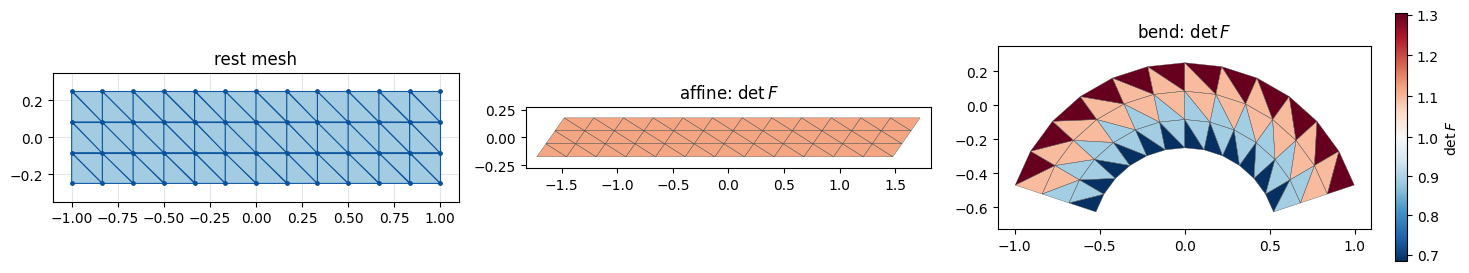

In [7]:
all_det = np.concatenate([det_affine, det_bend])
norm = TwoSlopeNorm(vmin=all_det.min(), vcenter=1.0, vmax=all_det.max())
fig, axes = plt.subplots(1, 3, figsize=(15, 3.4), gridspec_kw=dict(width_ratios=[1.0, 1.0, 1.15]))
utils.plot_mesh(axes[0], X_grid, T_grid, title="rest mesh", show_vertices=True)
utils.plot_scalar_field(axes[1], U_affine, T_grid, det_affine, title=r"affine: $\det F$",
                        cmap="RdBu_r", norm=norm, colorbar=False)
utils.plot_scalar_field(axes[2], U_bend, T_grid, det_bend, title=r"bend: $\det F$",
                        cmap="RdBu_r", norm=norm, label=r"$\det F$")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "mesh_det_F.png"),
                              copy_to=os.path.join(MEDIA_DIR, "001_mesh_det_F.png"))
plt.show()

## $D_s D_m^{-1}$ converges to $\partial x/\partial X$

For a non-affine map, one triangle's $F$ only approximates the Jacobian. Below, an equilateral triangle of
side $h$ shrinks around `X_PROBE`, and its $F$ is compared with the exact Jacobian of the bend. The error falls
linearly in $h$ (the fitted slope is printed; the dashed guide has slope 1), so on a fine mesh the per-element
$F$ approaches the continuum $\partial x/\partial X$.

error 1.70e-01 at h = 0.4  ->  5.18e-03 at h = 0.0125;  fitted slope 1.01


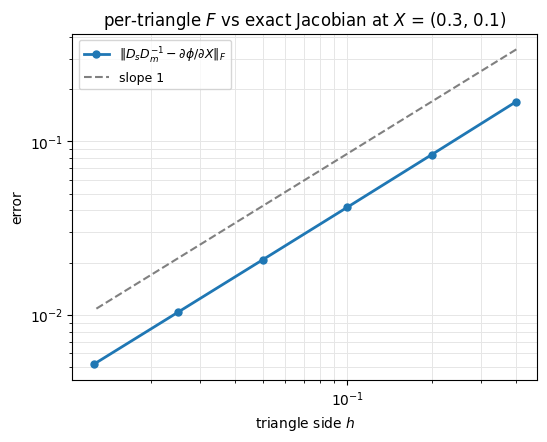

In [8]:
def bend_jacobian(p):
    """Exact Jacobian d(phi)/dX of the bend at one material point p."""
    Rb = BEND_RADIUS
    c, s = np.cos(p[0] / Rb), np.sin(p[0] / Rb)
    stretch = (Rb + p[1]) / Rb
    F_exact = np.array([[stretch * c, s], [-stretch * s, c]])
    return F_exact

p = np.array(X_PROBE)
F_exact = bend_jacobian(p)
unit_tri = (X - X.mean(axis=0)) / SIDE           # side-1 equilateral triangle centred on its centroid
errors = []
for h in H_LIST:
    X_small = p + h * unit_tri
    F_h = deformation_gradient_triangle(X_small, bend(X_small))
    errors.append(np.linalg.norm(F_h - F_exact))
slope = np.polyfit(np.log(H_LIST), np.log(errors), 1)[0]
print(f"error {errors[0]:.2e} at h = {H_LIST[0]:g}  ->  {errors[-1]:.2e} at h = {H_LIST[-1]:g};  fitted slope {slope:.2f}")

fig, ax = utils.loglog_plot(H_LIST, {r"$\|D_s D_m^{-1} - \partial\phi/\partial X\|_F$": errors},
                            xlabel="triangle side $h$", ylabel="error",
                            title=f"per-triangle $F$ vs exact Jacobian at $X$ = {tuple(X_PROBE)}",
                            figsize=(6, 4.5))
ax.loglog(H_LIST, 2 * errors[0] * np.array(H_LIST) / H_LIST[0], "--", color="0.5", label="slope 1")
ax.legend(fontsize=9)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "jacobian_convergence.png"),
                              copy_to=os.path.join(MEDIA_DIR, "001_jacobian_convergence.png"))
plt.show()

### Takeaways
* $F = D_s D_m^{-1}$: the deformed edges expressed in the rest-edge basis.
* It is the **local linear part** of the deformation, translation-free by construction.
* `simkit.deformation_gradient(X, T, U)` returns one (piecewise-constant) $F$ per element; every later tutorial calls it.
* As elements shrink, that $F$ converges to the Jacobian $\partial x/\partial X$ at first order.

Next we build intuition for what different $F$'s *look like*.